In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression,SGDRegressor
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.pipeline import Pipeline

In [14]:
X = 6 * np.random.rand(200, 1) - 3
y = 0.8 * X**2 + 0.9 * X + 2 + np.random.randn(200, 1)

# y = 0.8x^2 + 0.9x + 2

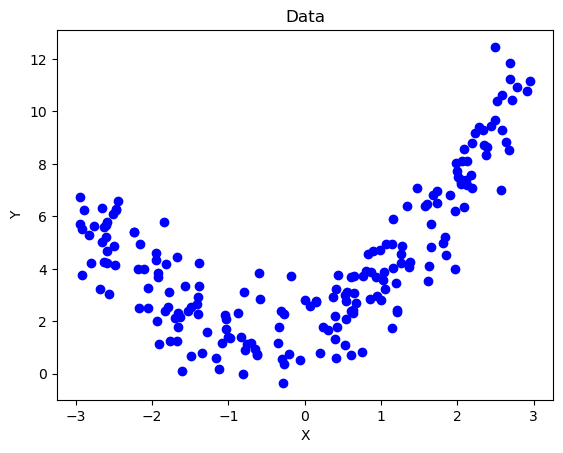

In [15]:
# Let us plot the datasets first to check how data looks like
plt.scatter(X[:,0] , y,color = 'b')
plt.title("Data")
plt.xlabel("X")
plt.ylabel("Y")
plt.show()

`Clearly we see that the data is not linear`

In [16]:
# Let us split this into Train and test datasets
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=.2 , random_state = 2)

In [17]:
print(f"Shape X_train -> {X_train.shape}")
print(f"Shape y_train -> {y_train.shape}")
print(f"Shape X_test -> {X_test.shape}")
print(f"Shape y_test -> {y_test.shape}")

Shape X_train -> (160, 1)
Shape y_train -> (160, 1)
Shape X_test -> (40, 1)
Shape y_test -> (40, 1)


In [18]:
y_train = y_train.ravel()
y_test = y_test.ravel()

In [19]:
lr = LinearRegression()

In [20]:
model_linear = lr.fit(X_train,y_train)

In [21]:
y_pred_linear = lr.predict(X_test)

In [22]:
residuals_linear = y_test - y_pred_linear

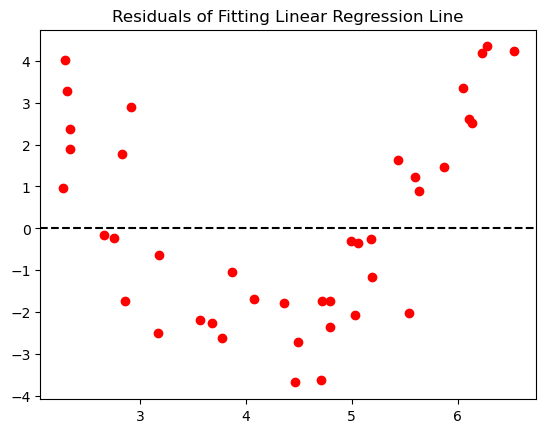

In [23]:
# Let us plot the residuals against y_pred and against input column
plt.scatter(y_pred_linear , residuals_linear , color='r')
plt.axhline(0 , linestyle='--' , color = 'k')
plt.title("Residuals of Fitting Linear Regression Line")
plt.show()

`Clearly the residuals are not randomly scattered`

In [24]:
# Checking and mean Standard deviation of Residuals of Linear Model
print(f"Mean -> {residuals_linear.mean()}") # Not Zero
print(residuals_linear.std())

Mean -> 0.12050572635000498
2.3583057714194378


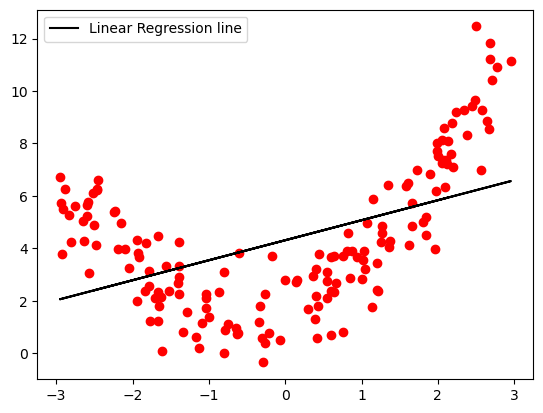

In [25]:
# Let us plot the regrssion line
plt.scatter(X_train,y_train , color='red')
plt.plot(X_train , lr.predict(X_train) , color = 'k' , label = 'Linear Regression line')
plt.legend()
plt.show()

In [26]:
# Let us find the r2 score
print(f"R2 Score for Linear Model-> {r2_score(y_test,y_pred_linear)}")

R2 Score for Linear Model-> 0.3176245382828621


#### Building the Polynomial Regression

In [27]:
poly = PolynomialFeatures(degree = 2)
X_train_trans = poly.fit_transform(X_train)
X_test_trans = poly.transform(X_test)

In [28]:
print(f"Before -> {X_train[0]}\nAfter -> {X_train_trans[0]}")

Before -> [2.12533005]
After -> [1.         2.12533005 4.51702781]


In [29]:
# now let us fit these values and find new model
lr_poly = LinearRegression()

In [30]:
# Only features will change the output will remain the same
model_poly = lr_poly.fit(X_train_trans , y_train)

In [31]:
y_pred_poly = model_poly.predict(X_test_trans)

In [32]:
residuals_poly = y_test - y_pred_poly

In [33]:
# Calculate R2 Score
print(f"r2 Score -> {r2_score(y_test , y_pred_poly)}")

r2 Score -> 0.8426757225688204


In [34]:
# Checking intercept and coefficients value
print(f"Intercept -> {lr_poly.intercept_}")
print(f"Coefficients -> {lr_poly.coef_}")

Intercept -> 1.764704988717205
Coefficients -> [0.         0.90954493 0.84090182]


In [35]:
X_new = np.linspace(-3,3,200).reshape(200,1)

In [36]:
X_new_trans = poly.transform(X_new)
# print(X_new_trans)

In [37]:
y_new = lr_poly.predict(X_new_trans)

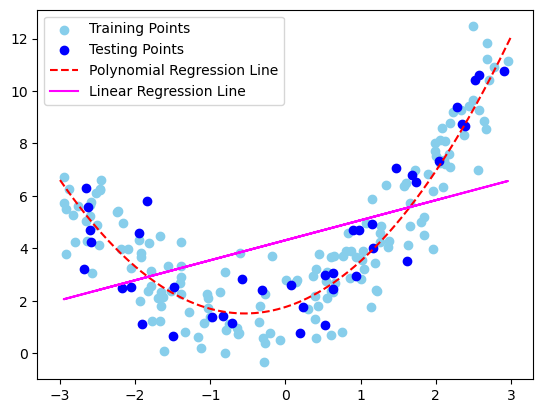

In [38]:
# Plotting the polynomial regression line and Linear regression line side by side
plt.scatter(X_train , y_train , color = 'skyblue' , label = 'Training Points')
plt.scatter(X_test , y_test , color = 'blue' , label = 'Testing Points')
plt.plot(X_new , y_new , color = 'red' , linestyle='--' , label ='Polynomial Regression Line')
plt.plot(X_train , lr.predict(X_train) , color = 'magenta' , linestyle='-' , label ='Linear Regression Line')
plt.legend()
plt.show()

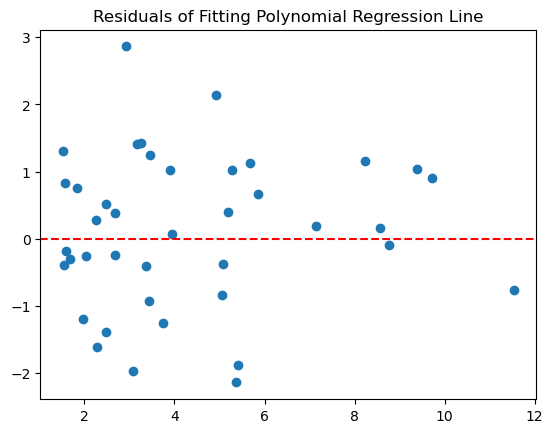

In [39]:
# Plotting Residuals poly against y_pred_poly
plt.scatter(y_pred_poly , residuals_poly)
plt.axhline(0 , color='red', linestyle = '--')
plt.title("Residuals of Fitting Polynomial Regression Line")
plt.show()

In [40]:
print(f"Mean -> {residuals_poly.mean()}") # Almost zero
print(residuals_poly.std())

Mean -> 0.11900412902286894
1.1275795469744756


##### Creating a function which can plot any degree polynomial

In [41]:
def PolynomialReg(d = 1):
    poly = PolynomialFeatures(degree = d , include_bias =True)
    std_scaler = StandardScaler()
    lin_reg = LinearRegression()
    polynomial_regression = Pipeline([
        ("poly_features" , poly) ,
        ("std_scaler" , std_scaler),
        ("lin_reg" , lin_reg)
    ])

    polynomial_regression.fit(X,y)
    X_new  = np.linspace(-3,3,200).reshape(200,1)
    X_new_poly = poly.transform(X_new)

    y_new = polynomial_regression.predict(X_new)

    plt.scatter(X , y , color = 'blue')
    plt.plot(X_new , y_new , color = 'red' ,linestyle = '--' ,label = f'Poly Reg Line(degree {d})')
    plt.legend()
    plt.show()

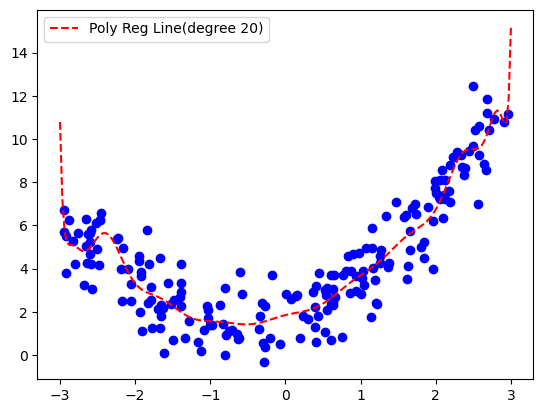

In [42]:
PolynomialReg(20)